# Дипломная работа: Детекция переутомления спортсмена
## v6.0 — Wrist-модель (PhysioNet + WSD4FEDSRM)

**Цель:** Автоматическое определение переутомления спортсмена по данным запястного носимого устройства

**Версия v6.0 — Фокус на запястье:**
- Датасеты: **PhysioNet** (Empatica E4, запястье) + **WSD4FEDSRM** (IMU предплечье/кисть + PPG)
- Исключены: Zenodo (поясница) и 4TU (таз/ноги) — нет запястных данных
- Двухветочная архитектура: IMU + Physio
- **Focal Loss** (γ=2.0) вместо LabelSmoothingBCE
- **Class+Domain WeightedRandomSampler** (балансирует и классы, и домены)
- Единый CONFIG для всех гиперпараметров

**Данные (dual-branch):**
- `X_imu`:    (N, 100, 6) — ax, ay, az, gx, gy, gz
- `X_physio`: (N, 100, 4) — bvp, eda, temp, hr
- `has_physio`: bool mask (PhysioNet=True, WSD4FEDSRM=False)

**Модель:** FatigueWristNet (IMU Encoder + Physio Encoder → Classifier)

In [4]:
# ── 1. Imports ──
import os, sys, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, precision_recall_curve,
    auc, roc_curve,
)
from scipy.interpolate import CubicSpline
from scipy.signal import resample as sp_resample
from imblearn.over_sampling import SMOTE

sys.path.insert(0, str(Path.cwd().parent))
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

SEED = 133214

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Seed: {SEED}")

PyTorch: 2.10.0+cu130, CUDA: True
Device: cuda
Seed: 133214


## 1. Единый CONFIG (v6.0)

Все гиперпараметры модели и обучения в одном месте.
Модули выполняют деление (`// 2`, `// 4`) **внутри** `__init__`, CONFIG содержит только базовые значения.

In [5]:
# Best
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.003, 'patience': 6, 'min_delta': 2e-05, 'imu_channels': 6, 'encoder_channels': 32, 'encoder_dropout': 0.35, 'kernel_sizes': [7, 5, 3], 'physio_channels': 4, 'physio_encoder_channels': 16, 'classifier_dropout': 0.5, 'focal_gamma': 2.0, 'min_precision_for_recall': 0.3}

# Good 
# {'batch_size': 32, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.005, 'patience': 6, 'min_delta': 0.0001, 'imu_channels': 6, 'encoder_channels': 32, 'encoder_dropout': 0.35, 'kernel_sizes': [7, 5, 3], 'physio_channels': 4, 'physio_encoder_channels': 16, 'classifier_dropout': 0.5, 'focal_gamma': 1.0, 'min_precision_for_recall': 0.3}

# Bad config 
# {'batch_size': 32, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.005, 'patience': 6, 'min_delta': 0.0001, 'imu_channels': 6, 'encoder_channels': 32, 'encoder_dropout': 0.375, 'kernel_sizes': [7, 5, 3], 'physio_channels': 4, 'physio_encoder_channels': 16, 'classifier_dropout': 0.55, 'focal_gamma': 2.0, 'min_precision_for_recall': 0.3}
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.005, 'patience': 5, 'min_delta': 0.0001, 'imu_channels': 6, 'encoder_channels': 32, 'encoder_dropout': 0.375, 'kernel_sizes': [7, 5, 3], 'physio_channels': 4, 'physio_encoder_channels': 16, 'classifier_dropout': 0.55, 'focal_gamma': 2.0, 'min_precision_for_recall': 0.3}

In [6]:
CONFIG = {
    # --- Training ---
    'batch_size': 128,
    'epochs': 50,
    'lr': 1e-4,
    'weight_decay': 3e-3,
    'patience': 6,
    'min_delta': 2e-4,

    # --- Architecture: IMU Encoder ---
    'imu_channels': 6,
    'encoder_channels': 32,
    'encoder_dropout': 0.35,
    'kernel_sizes': [7, 5, 3],

    # --- Architecture: Physio Encoder ---
    'physio_channels': 4,
    'physio_encoder_channels': 16,

    # --- Architecture: Classifier ---
    'classifier_dropout': 0.5,

    # --- Focal Loss ---
    'focal_gamma': 2.0,

    # --- Evaluation ---
    'min_precision_for_recall': 0.3,
}

print("CONFIG v6.0:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


CONFIG v6.0:
  batch_size: 128
  epochs: 50
  lr: 0.0001
  weight_decay: 0.003
  patience: 6
  min_delta: 0.0002
  imu_channels: 6
  encoder_channels: 32
  encoder_dropout: 0.35
  kernel_sizes: [7, 5, 3]
  physio_channels: 4
  physio_encoder_channels: 16
  classifier_dropout: 0.5
  focal_gamma: 2.0
  min_precision_for_recall: 0.3


## 2.5. Расширение WSD4FEDSRM (скользящие суб-окна)

WSD4FEDSRM имеет мало окон на субъект (~32). Увеличиваем количество через скользящие суб-окна
с перекрытием 50% внутри каждого исходного 100-точечного окна → каждое окно порождает 3 новых.

In [7]:
# ── Project root & paths ──
def find_project_root(marker='config.yaml', start=None, max_levels=5):
    current = Path(start or os.getcwd()).resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(f"Marker '{marker}' not found from {os.getcwd()}")

PROJECT_ROOT = find_project_root('config.yaml')
DATA_FILE = PROJECT_ROOT / 'data' / 'processed' / 'composite_full.npz'
RESULTS_DIR = (PROJECT_ROOT / 'results_v6_wrist').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# v6.0: only wrist-related domains
EXPECTED_DOMAINS = {'physionet', 'wsd4fedsrm'}

print(f"Project root: {PROJECT_ROOT}")
print(f"Data file:    {DATA_FILE}")
print(f"Results dir:  {RESULTS_DIR}")

# ── Load & filter ──
print(f"\nLoading {DATA_FILE.name}...")
data = np.load(DATA_FILE, allow_pickle=True)

X_imu_raw = data['X_imu'].astype(np.float32)
X_physio_raw = data['X_physio'].astype(np.float32)
y_raw = data['y'].astype(np.int64)
subjects_raw = data['pids']
domains_raw = data['domains']
has_physio_raw = data['has_physio'].astype(bool)

# Filter to wrist domains
keep = np.isin(domains_raw, list(EXPECTED_DOMAINS))
X_imu_filt = X_imu_raw[keep]
X_physio_filt = X_physio_raw[keep]
y_filt = y_raw[keep]
subjects_filt = subjects_raw[keep]
domains_filt = domains_raw[keep]
has_physio_filt = has_physio_raw[keep]

print(f"\nFiltered to wrist domains:")
print(f"   Total:     {keep.sum()} windows (excluded {(~keep).sum()} Zenodo/4TU)")
print(f"   X_imu:     {X_imu_filt.shape}")
print(f"   X_physio:  {X_physio_filt.shape}")
print(f"   Subjects:  {len(np.unique(subjects_filt))}")
print(f"   Domains:   {list(np.unique(domains_filt))}")
print(f"   has_physio: {has_physio_filt.sum()}/{len(has_physio_filt)}")
print(f"   NaN IMU: {np.isnan(X_imu_filt).sum()}, Physio: {np.isnan(X_physio_filt).sum()}")

# ── WSD4FEDSRM sub-windowing: скользящие окна с перекрытием ──
# Каждое исходное 100-точечное окно → 3 суб-окна (60% длины, шаг 20%)
WSD_SUB_CROP = 0.6     # доля от исходного окна
WSD_SUB_STRIDE = 0.2   # шаг в долях
TARGET_LEN = 100        # ресемпл обратно до 100

wsd_mask = domains_filt == 'wsd4fedsrm'
other_mask = ~wsd_mask

print(f"\n🔧 WSD4FEDSRM sub-windowing:")
print(f"   До: {wsd_mask.sum()} окон WSD4FEDSRM")

wsd_imu = X_imu_filt[wsd_mask]
wsd_physio = X_physio_filt[wsd_mask]
wsd_y = y_filt[wsd_mask]
wsd_subj = subjects_filt[wsd_mask]
wsd_hp = has_physio_filt[wsd_mask]

new_imu, new_physio, new_y, new_subj, new_hp = [], [], [], [], []
T = wsd_imu.shape[1]
crop_len = int(T * WSD_SUB_CROP)
stride_pts = int(T * WSD_SUB_STRIDE)

for i in range(len(wsd_imu)):
    # Оригинальное окно сохраняем
    new_imu.append(wsd_imu[i])
    new_physio.append(wsd_physio[i])
    new_y.append(wsd_y[i])
    new_subj.append(wsd_subj[i])
    new_hp.append(wsd_hp[i])
    # Суб-окна
    for start in range(0, T - crop_len + 1, stride_pts):
        if start == 0 and crop_len == T:
            continue  # это дубль оригинала
        seg_imu = wsd_imu[i, start:start + crop_len, :]
        seg_physio = wsd_physio[i, start:start + crop_len, :]
        # Ресемплирование обратно до TARGET_LEN
        resampled_imu = sp_resample(seg_imu, TARGET_LEN, axis=0).astype(np.float32)
        resampled_physio = sp_resample(seg_physio, TARGET_LEN, axis=0).astype(np.float32)
        new_imu.append(resampled_imu)
        new_physio.append(resampled_physio)
        new_y.append(wsd_y[i])
        new_subj.append(wsd_subj[i])
        new_hp.append(wsd_hp[i])

wsd_imu_exp = np.stack(new_imu)
wsd_physio_exp = np.stack(new_physio)
wsd_y_exp = np.array(new_y, dtype=np.int64)
wsd_subj_exp = np.array(new_subj)
wsd_hp_exp = np.array(new_hp)

print(f"   После: {len(wsd_y_exp)} окон WSD4FEDSRM (×{len(wsd_y_exp)/wsd_mask.sum():.1f})")

# Склеиваем обратно
X_imu_all = np.concatenate([X_imu_filt[other_mask], wsd_imu_exp], axis=0)
X_physio_all = np.concatenate([X_physio_filt[other_mask], wsd_physio_exp], axis=0)
y_all = np.concatenate([y_filt[other_mask], wsd_y_exp])
subjects = np.concatenate([subjects_filt[other_mask], wsd_subj_exp])
domains = np.concatenate([domains_filt[other_mask], np.array(['wsd4fedsrm'] * len(wsd_y_exp))])
has_physio = np.concatenate([has_physio_filt[other_mask], wsd_hp_exp])

print(f"\n   Итого: {len(y_all)} окон ({X_imu_all.shape})")
print(f"   Subjects: {len(np.unique(subjects))}")

Project root: D:\Github\afc_lab
Data file:    D:\Github\afc_lab\data\processed\composite_full.npz
Results dir:  D:\Github\afc_lab\results_v6_wrist

Loading composite_full.npz...

Filtered to wrist domains:
   Total:     24157 windows (excluded 22416 Zenodo/4TU)
   X_imu:     (24157, 100, 6)
   X_physio:  (24157, 100, 4)
   Subjects:  65
   Domains:   [np.str_('physionet'), np.str_('wsd4fedsrm')]
   has_physio: 23034/24157
   NaN IMU: 0, Physio: 0

🔧 WSD4FEDSRM sub-windowing:
   До: 1123 окон WSD4FEDSRM
   После: 4492 окон WSD4FEDSRM (×4.0)

   Итого: 27526 окон ((27526, 100, 6))
   Subjects: 65


In [8]:
# ── Dataset statistics ──
df_meta = pd.DataFrame({
    'sid': subjects, 'domain': domains, 'y': y_all, 'has_physio': has_physio,
})

print("=" * 60)
print("DATASET STATISTICS (v6.0: PhysioNet + WSD4FEDSRM)")
print("=" * 60)

print("\n📊 По доменам:")
for dom in np.unique(domains):
    m = domains == dom
    n, pos, subj = m.sum(), y_all[m].sum(), len(np.unique(subjects[m]))
    hp = has_physio[m].sum()
    print(f"  {dom:15s}: {n:>6} окон, {subj:>3} субъ., "
          f"pos={pos/n:.1%}, has_physio={hp}/{n}")

print(f"\n📊 Баланс классов: {y_all.mean():.2%} fatigue ({y_all.sum()}/{len(y_all)})")

print("\n📊 Окон/субъект:")
for dom in np.unique(domains):
    m = domains == dom
    counts = [np.sum(subjects[m] == s) for s in np.unique(subjects[m])]
    print(f"  {dom:15s}: median={np.median(counts):.0f}, "
          f"min={np.min(counts)}, max={np.max(counts)}")

DATASET STATISTICS (v6.0: PhysioNet + WSD4FEDSRM)

📊 По доменам:
  physionet      :  23034 окон,  31 субъ., pos=43.2%, has_physio=23034/23034
  wsd4fedsrm     :   4492 окон,  34 субъ., pos=71.1%, has_physio=0/4492

📊 Баланс классов: 47.78% fatigue (13153/27526)

📊 Окон/субъект:
  physionet      : median=642, min=225, max=1123
  wsd4fedsrm     : median=130, min=72, max=268


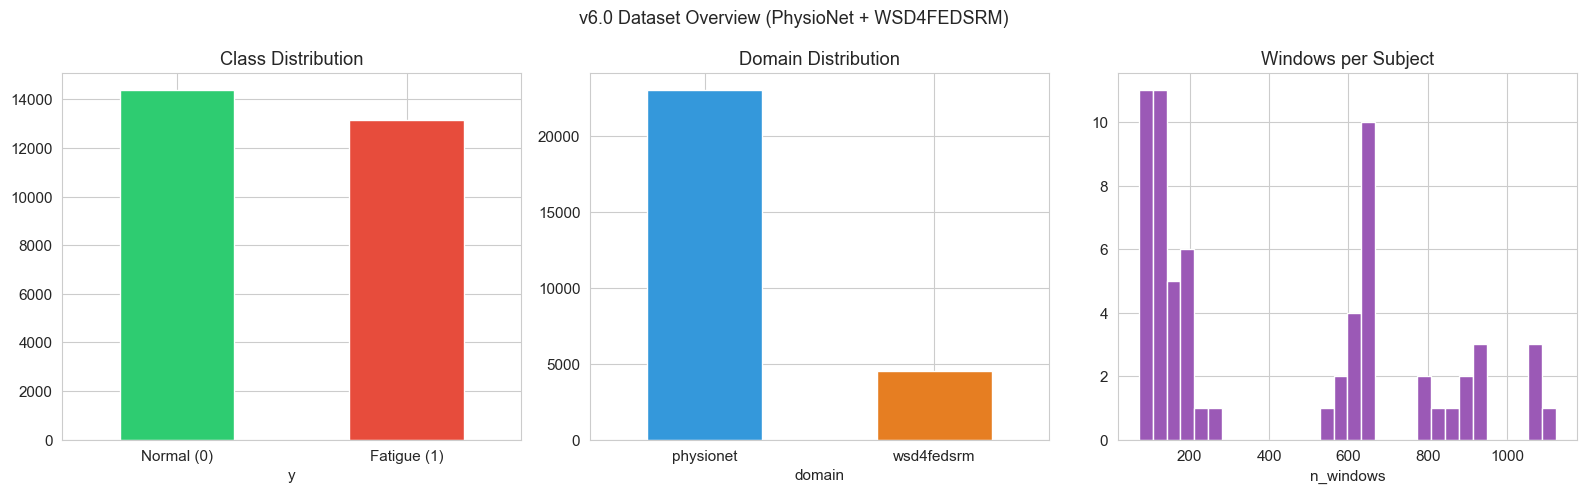

In [9]:
# ── Distribution plots ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Classes
df_meta['y'].value_counts().sort_index().plot.bar(
    ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Normal (0)', 'Fatigue (1)'], rotation=0)

# Domains
df_meta['domain'].value_counts().plot.bar(
    ax=axes[1], color=['#3498db', '#e67e22'])
axes[1].set_title('Domain Distribution')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Windows per subject
counts_per_subj = df_meta.groupby('sid').size()
counts_per_subj.hist(ax=axes[2], bins=30, color='#9b59b6', edgecolor='white')
axes[2].set_title('Windows per Subject')
axes[2].set_xlabel('n_windows')

plt.suptitle('v6.0 Dataset Overview (PhysioNet + WSD4FEDSRM)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'dataset_overview.png')
plt.show()

## 3. Подготовка данных

- Subject-level split (60/20/20), стратифицированный по доменам
- **Сильная аугментация IMU**: всегда применяется 3-5 техник (noise, time_warp, scale, crop, reverse, rotate, channel_dropout, mixup-jitter)
- **Целевая аугментация**: borderline-семплы определяются по дисперсии сигнала и получают усиленную обработку
- **SMOTE**: синтез новых семплов в пространстве признаков для баланса классов в тренировочном наборе
- `FatigueDataset` возвращает `(x_imu, x_physio, has_physio, y)` — 4 элемента

In [10]:
# ── Subject-level split ──

def create_subject_split(subjects, domains, y, test_size=0.2, val_size=0.2, seed=SEED):
    subj_df = pd.DataFrame({'sid': subjects, 'domain': domains}).drop_duplicates('sid')
    sids = subj_df['sid'].to_numpy(dtype=object)
    doms = subj_df['domain'].to_numpy(dtype=object)

    strat = doms if len(np.unique(doms)) > 1 else None
    sid_tv, sid_test = train_test_split(
        sids, test_size=test_size, random_state=seed, stratify=strat)

    val_rel = val_size / (1.0 - test_size)
    sid_to_domain = dict(zip(sids, doms))
    tv_doms = np.array([sid_to_domain[s] for s in sid_tv])
    strat_v = tv_doms if len(np.unique(tv_doms)) > 1 else None
    sid_train, sid_val = train_test_split(
        sid_tv, test_size=val_rel, random_state=seed, stratify=strat_v)

    tr_idx = np.where(np.isin(subjects, sid_train))[0]
    va_idx = np.where(np.isin(subjects, sid_val))[0]
    te_idx = np.where(np.isin(subjects, sid_test))[0]

    for name, idx in [('Train', tr_idx), ('Val', va_idx), ('Test', te_idx)]:
        if len(np.unique(y[idx])) < 2:
            raise ValueError(f"{name} split has only one class")

    return tr_idx, va_idx, te_idx

train_idx, val_idx, test_idx = create_subject_split(subjects, domains, y_all)

for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    dom_counts = dict(zip(*np.unique(domains[idx], return_counts=True)))
    cls = np.bincount(y_all[idx].astype(int), minlength=2)
    print(f"{name:5s}: {len(idx):>6} wins, {len(np.unique(subjects[idx]))} subj | "
          f"doms={dom_counts} | 0→{cls[0]}, 1→{cls[1]} ({y_all[idx].mean():.1%} pos)")


Train:  16983 wins, 39 subj | doms={np.str_('physionet'): np.int64(14379), np.str_('wsd4fedsrm'): np.int64(2604)} | 0→9006, 1→7977 (47.0% pos)
Val  :   5380 wins, 13 subj | doms={np.str_('physionet'): np.int64(4524), np.str_('wsd4fedsrm'): np.int64(856)} | 0→2845, 1→2535 (47.1% pos)
Test :   5163 wins, 13 subj | doms={np.str_('physionet'): np.int64(4131), np.str_('wsd4fedsrm'): np.int64(1032)} | 0→2522, 1→2641 (51.2% pos)


### Augmentation

In [11]:
# ── Augmentation (IMU + Physio) — Сильная целевая аугментация ──

# ---------- Базовые трансформации ----------

def add_gaussian_noise(x, sigma=0.05):
    return x + np.random.normal(0, sigma, x.shape).astype(x.dtype)

def time_warp(x, sigma=0.2, knots=4):
    T, C = x.shape
    tt = np.linspace(0, T - 1, knots + 2)
    warp = np.concatenate([[0], np.random.normal(0, sigma * T, knots), [0]])
    warp_fn = CubicSpline(tt, warp)
    t_orig = np.arange(T)
    t_warped = np.clip(t_orig + warp_fn(t_orig), 0, T - 1)
    return np.stack([CubicSpline(t_orig, x[:, c])(t_warped)
                     for c in range(C)], axis=-1).astype(x.dtype)

def channel_dropout(x, p=0.2):
    x = x.copy()
    for c in range(x.shape[1]):
        if np.random.rand() < p:
            x[:, c] = 0.0
    return x

def magnitude_scale(x, lo=0.7, hi=1.3):
    return x * np.random.uniform(lo, hi, (1, x.shape[1])).astype(x.dtype)

def window_slice(x, crop_lo=0.6, crop_hi=0.9):
    T, C = x.shape
    crop = np.random.uniform(crop_lo, crop_hi)
    L = max(int(T * crop), 10)
    s = np.random.randint(0, T - L + 1)
    return sp_resample(x[s:s + L], T, axis=0).astype(x.dtype)

def time_reverse(x):
    return x[::-1].copy()

def imu_rotate(x, max_deg=20.0):
    def _rot():
        theta = np.deg2rad(np.random.uniform(-max_deg, max_deg))
        n = np.random.randn(3)
        n /= (np.linalg.norm(n) + 1e-8)
        K = np.array([[0, -n[2], n[1]], [n[2], 0, -n[0]], [-n[1], n[0], 0]])
        return np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * K @ K
    x = x.copy()
    x[:, :3] = x[:, :3] @ _rot().T
    if x.shape[1] >= 6:
        x[:, 3:6] = x[:, 3:6] @ _rot().T
    return x.astype(np.float32)

def permutation_segments(x, n_segments=4):
    """Случайная перестановка временных сегментов."""
    T, C = x.shape
    seg_len = T // n_segments
    if seg_len < 2:
        return x
    segments = [x[i * seg_len:(i + 1) * seg_len] for i in range(n_segments)]
    remainder = x[n_segments * seg_len:]
    np.random.shuffle(segments)
    result = np.concatenate(segments + ([remainder] if len(remainder) else []), axis=0)
    return result.astype(x.dtype)

def frequency_mask(x, max_mask_ratio=0.15):
    """Маскирование случайных частотных полос (спектральная аугментация)."""
    T, C = x.shape
    x_out = x.copy()
    for c in range(C):
        freq = np.fft.rfft(x[:, c])
        n_freq = len(freq)
        mask_len = max(1, int(n_freq * max_mask_ratio))
        start = np.random.randint(0, max(1, n_freq - mask_len))
        freq[start:start + mask_len] = 0
        x_out[:, c] = np.fft.irfft(freq, n=T)
    return x_out.astype(x.dtype)


# ---------- Определение borderline-семплов ----------

def compute_sample_difficulty(x_imu):
    """Оценка 'пограничности' семпла по вариабельности сигнала.

    Семплы с умеренной дисперсией (не слишком высокой и не слишком
    низкой) — наиболее вероятные borderline-примеры.
    Возвращает score ∈ [0, 1]: чем выше, тем ближе семпл к границе.
    """
    per_channel_std = np.std(x_imu, axis=0)  # (C,)
    mean_std = np.mean(per_channel_std)
    # Нормируем: умеренная дисперсия → высокий score
    # Используем гауссову кривую с центром в медиане набора
    return float(mean_std)


# ---------- Сильная аугментация ----------

# Пул трансформаций для IMU
IMU_TRANSFORMS = [
    ('noise',     lambda x: add_gaussian_noise(x, sigma=np.random.uniform(0.03, 0.10))),
    ('time_warp', lambda x: time_warp(x, sigma=np.random.uniform(0.15, 0.35), knots=4)),
    ('scale',     lambda x: magnitude_scale(x, 0.7, 1.3)),
    ('crop',      lambda x: window_slice(x, 0.6, 0.9)),
    ('reverse',   lambda x: time_reverse(x)),
    ('rotate',    lambda x: imu_rotate(x, max_deg=20.0)),
    ('permute',   lambda x: permutation_segments(x, n_segments=np.random.randint(3, 6))),
    ('freq_mask', lambda x: frequency_mask(x, max_mask_ratio=0.15)),
]

PHYSIO_TRANSFORMS = [
    ('noise',     lambda x: add_gaussian_noise(x, sigma=np.random.uniform(0.02, 0.06))),
    ('scale',     lambda x: magnitude_scale(x, 0.85, 1.15)),
    ('time_warp', lambda x: time_warp(x, sigma=0.1, knots=3)),
]


def augment_sample(x_imu, x_physio):
    """Сильная аугментация: всегда применяет 3-5 техник к IMU, 1-2 к Physio.

    Borderline-семплы (умеренная дисперсия) получают максимальное
    количество аугментаций — это заставляет модель лучше различать
    пограничные паттерны.
    """
    difficulty = compute_sample_difficulty(x_imu)

    # Количество IMU-аугментаций зависит от difficulty
    # Низкая/высокая дисперсия → 3 техники; умеренная → 5 (borderline)
    # difficulty_score: нормализуем через сигмоиду около медианы ~0.8
    border_score = 1.0 - abs(difficulty - 0.8) / max(difficulty + 0.3, 1e-6)
    border_score = np.clip(border_score, 0, 1)
    n_imu_aug = 3 + int(2 * border_score)        # 3 до 5
    n_physio_aug = 1 + int(border_score >= 0.5)   # 1 или 2

    # Выбираем случайные трансформации (без повторений)
    imu_choices = np.random.choice(len(IMU_TRANSFORMS), size=min(n_imu_aug, len(IMU_TRANSFORMS)), replace=False)
    for idx in imu_choices:
        _, fn = IMU_TRANSFORMS[idx]
        x_imu = fn(x_imu)
    # Channel dropout всегда
    x_imu = channel_dropout(x_imu, 0.2)

    # Physio аугментация
    physio_choices = np.random.choice(len(PHYSIO_TRANSFORMS), size=min(n_physio_aug, len(PHYSIO_TRANSFORMS)), replace=False)
    for idx in physio_choices:
        _, fn = PHYSIO_TRANSFORMS[idx]
        x_physio = fn(x_physio)

    return x_imu, x_physio


# ---------- SMOTE для тренировочного набора ----------

def apply_smote_dual_branch(X_imu, X_physio, y, has_physio_arr, k_neighbors=5, random_state=SEED):
    """SMOTE в объединённом пространстве IMU+Physio.

    Раскладываем (N, T, C_imu) + (N, T, C_physio) → (N, T*(C_imu+C_physio)),
    применяем SMOTE, затем восстанавливаем обратно.
    """
    N, T, C_imu = X_imu.shape
    C_physio = X_physio.shape[2]

    # Flatten
    flat_imu = X_imu.reshape(N, -1)       # (N, T*C_imu)
    flat_physio = X_physio.reshape(N, -1)  # (N, T*C_physio)
    X_flat = np.hstack([flat_imu, flat_physio])  # (N, T*(C_imu+C_physio))

    # Адаптивное k_neighbors — не больше чем (min_class - 1)
    class_counts = np.bincount(y.astype(int))
    min_class_count = class_counts.min()
    k = min(k_neighbors, min_class_count - 1)
    if k < 1:
        print("   ⚠️ SMOTE: недостаточно примеров для k_neighbors, пропуск")
        return X_imu, X_physio, y, has_physio_arr

    smote = SMOTE(k_neighbors=k, random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X_flat, y.astype(int))

    # Unflatten
    N_new = len(y_resampled)
    imu_flat = X_resampled[:, :T * C_imu]
    physio_flat = X_resampled[:, T * C_imu:]
    X_imu_new = imu_flat.reshape(N_new, T, C_imu).astype(np.float32)
    X_physio_new = physio_flat.reshape(N_new, T, C_physio).astype(np.float32)

    # has_physio для новых семплов: наследуем от ближайшего оригинала
    hp_new = np.zeros(N_new, dtype=bool)
    hp_new[:N] = has_physio_arr
    # Синтетические семплы: если большинство класса имело physio — тоже True
    for cls in [0, 1]:
        cls_mask_orig = y.astype(int) == cls
        if cls_mask_orig.any():
            physio_ratio = has_physio_arr[cls_mask_orig].mean()
            cls_mask_new = (y_resampled == cls) & (np.arange(N_new) >= N)
            hp_new[cls_mask_new] = physio_ratio > 0.5

    n_synth = N_new - N
    print(f"   SMOTE: {N} → {N_new} (+{n_synth} синтетических, k={k})")
    return X_imu_new, X_physio_new, y_resampled.astype(np.int64), hp_new


# ── Dataset (dual-branch: IMU + Physio) ──

class FatigueDataset(Dataset):
    """Returns (x_imu, x_physio, has_physio, y) per sample."""

    def __init__(self, X_imu, X_physio, y, has_physio, augment=False):
        self.X_imu = X_imu.astype(np.float32)
        self.X_physio = X_physio.astype(np.float32)
        self.y = y.astype(np.float32)
        self.has_physio = has_physio.astype(np.float32)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        xi, xp = self.X_imu[idx].copy(), self.X_physio[idx].copy()
        if self.augment:
            xi, xp = augment_sample(xi, xp)
        return (torch.FloatTensor(xi),
                torch.FloatTensor(xp),
                torch.tensor(self.has_physio[idx], dtype=torch.float32),
                torch.tensor(self.y[idx], dtype=torch.float32))

print("✅ Сильная аугментация (8 IMU + 3 Physio + SMOTE + borderline-targeting) + FatigueDataset ready")

✅ Сильная аугментация (8 IMU + 3 Physio + SMOTE + borderline-targeting) + FatigueDataset ready


## 4. Архитектура модели (v6.0: FatigueWristNet)

Двухветочная CNN с Temporal Attention (IMU) и GAP (Physio):

```
IMU Input (B, 100, 6)              Physio Input (B, 100, 4)
      ↓                                  ↓
Conv1D→BN→ReLU→Pool→Drop ×3        Conv1D→BN→ReLU→Drop
      ↓                            Conv1D→BN→ReLU→GAP
TemporalAttention → (B, C_imu)         → (B, C_physio) × has_physio_mask
                  ↓
         Concat → (B, C_imu + C_physio)
                  ↓
     FC → ReLU → Dropout → FC → 1
```

**Деление (`// 4`, `// 2`) выполняется внутри `__init__` модулей, не снаружи.**

In [12]:
# ── Model components ──

class TemporalAttention(nn.Module):
    """Single-head temporal attention. Input: (B, C, T) → Output: (B, C)"""
    def __init__(self, channels):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(channels, channels // 4, kernel_size=1),  # деление внутри
            nn.Tanh(),
            nn.Conv1d(channels // 4, 1, kernel_size=1),
        )

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=-1)  # (B, 1, T)
        return (x * w).sum(dim=-1)                 # (B, C)


class IMUEncoderWithAttention(nn.Module):
    """3×Conv1D + TemporalAttention for IMU data."""
    def __init__(self, in_channels, out_channels, dropout, kernel_sizes):
        super().__init__()
        k1, k2, k3 = kernel_sizes
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, k1, padding=k1 // 2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, k2, padding=k2 // 2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, k3, padding=k3 // 2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
        )
        self.attention = TemporalAttention(out_channels)

    def forward(self, x):
        x = x.transpose(1, 2)  # (B, T, C) → (B, C, T)
        x = self.conv3(self.conv2(self.conv1(x)))
        return self.attention(x)


class PhysioEncoder(nn.Module):
    """2×Conv1D + GAP for physiological signals (BVP, EDA, TEMP, HR)."""
    def __init__(self, in_channels, out_channels, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True), nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x):
        return self.net(x.transpose(1, 2)).squeeze(-1)  # (B, out_ch)


class FatigueWristNet(nn.Module):
    """
    Dual-branch CNN for wrist fatigue detection (v6.0).
    IMU encoder (3×Conv + Attention) + Physio encoder (2×Conv + GAP) → Classifier.
    LayerNorm before classifier stabilises training across domain-mixed batches.
    """
    def __init__(self, cfg):
        super().__init__()
        enc_ch = cfg['encoder_channels']
        physio_enc_ch = cfg['physio_encoder_channels']

        self.imu_encoder = IMUEncoderWithAttention(
            in_channels=cfg['imu_channels'],
            out_channels=enc_ch,
            dropout=cfg['encoder_dropout'],
            kernel_sizes=cfg['kernel_sizes'],
        )
        self.physio_encoder = PhysioEncoder(
            in_channels=cfg['physio_channels'],
            out_channels=physio_enc_ch,
            dropout=cfg['encoder_dropout'],
        )

        feat_dim = enc_ch + physio_enc_ch
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),                # нормализация перед FC
            nn.Linear(feat_dim, feat_dim // 2),    # деление внутри
            nn.ReLU(True),
            nn.Dropout(cfg['classifier_dropout']),
            nn.Linear(feat_dim // 2, 1),           # деление внутри
        )

    def forward(self, x_imu, x_physio, has_physio=None):
        imu_feat = self.imu_encoder(x_imu)            # (B, enc_ch)
        physio_feat = self.physio_encoder(x_physio)    # (B, physio_enc_ch)
        # Mask physio features for samples without physio data
        if has_physio is not None:
            physio_feat = physio_feat * has_physio.unsqueeze(-1)
        combined = torch.cat([imu_feat, physio_feat], dim=1)
        return self.classifier(combined).squeeze(-1)

    def predict_proba(self, x_imu, x_physio, has_physio=None):
        with torch.no_grad():
            return torch.sigmoid(self.forward(x_imu, x_physio, has_physio))

print("✅ FatigueWristNet defined (IMU + Physio dual-branch, LayerNorm classifier)")


✅ FatigueWristNet defined (IMU + Physio dual-branch, LayerNorm classifier)


In [13]:
# ── Model instantiation ──
model = FatigueWristNet(CONFIG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())

print("=" * 60)
print("  FatigueWristNet v6.0 (dual-branch, wrist-focused)")
print("=" * 60)
for name, mod in [('IMU Encoder', model.imu_encoder),
                  ('Physio Encoder', model.physio_encoder),
                  ('Classifier', model.classifier)]:
    p = sum(x.numel() for x in mod.parameters())
    print(f"  {name:25s}: {p:>8,}")
print(f"  {'TOTAL':25s}: {n_params:>8,}")

# Smoke test
xi = torch.randn(4, 100, CONFIG['imu_channels']).to(DEVICE)
xp = torch.randn(4, 100, CONFIG['physio_channels']).to(DEVICE)
hp = torch.ones(4).to(DEVICE)
out = model(xi, xp, hp)
print(f"\n  Smoke test output: {out.shape} ✅")

  FatigueWristNet v6.0 (dual-branch, wrist-focused)
  IMU Encoder              :   10,097
  Physio Encoder           :    1,184
  Classifier               :    1,297
  TOTAL                    :   12,578

  Smoke test output: torch.Size([4]) ✅


## 5. Обучение (v6.0: Focal Loss + class-domain weighting)

**Изменения v6.0 vs v5.1:**
- **Focal Loss** (γ=2.0) вместо LabelSmoothingBCE — фокусирует градиенты на трудных примерах
- **Class+Domain sampler** — балансирует и домены (PhysioNet 95% → WSD 5%), и классы (норма/усталость)
- CONFIG сохраняется в checkpoint вместе с весами и порогом
- Recall-optimized threshold selection для лучшего детектирования усталости

In [14]:
# ── Focal Loss ──

class FocalLoss(nn.Module):
    """Focal Loss: down-weights easy examples, focuses on hard ones."""
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        return (focal_weight * bce).mean()


# ── Class+Domain combined weights ──

def compute_class_domain_weights(y, domains):
    """Each (class, domain) group contributes equally to sampling."""
    weights = np.zeros(len(y), dtype=np.float64)
    unique_doms = np.unique(domains)
    for dom in unique_doms:
        for cls in [0, 1]:
            mask = (domains == dom) & (y == cls)
            n = mask.sum()
            if n > 0:
                weights[mask] = len(y) / (2 * len(unique_doms) * n)
    return weights


def compute_pos_weight(y):
    n_pos = y.sum()
    return (len(y) - n_pos) / max(n_pos, 1)


# ── Metrics ──

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
    }
    if np.unique(y_true).size >= 2:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
        pr, rc, _ = precision_recall_curve(y_true, y_prob)
        metrics['pr_auc'] = auc(rc, pr)
    else:
        metrics['roc_auc'] = metrics['pr_auc'] = np.nan
    return metrics, y_pred


def find_best_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 181):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t, best_f1


def find_recall_optimized_threshold(y_true, y_prob, min_precision=0.3):
    """Find threshold maximizing recall(fatigue) with precision >= min_precision."""
    best_t, best_rec = 0.5, 0.0
    for t in np.linspace(0.05, 0.95, 181):
        pred = (y_prob >= t).astype(int)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        prec = tp / (tp + fp + 1e-8)
        rec = tp / (tp + fn + 1e-8)
        if prec >= min_precision and rec > best_rec:
            best_rec, best_t = rec, float(t)
    return best_t, best_rec


# ── Early Stopping with EMA smoothing ──

class EarlyStopping:
    """EMA-smoothed early stopping: reduces sensitivity to per-epoch fluctuations.

    The monitor signal is: ema = alpha * raw_score + (1 - alpha) * ema_prev
    Only the smoothed value is used to decide patience / best model.
    """
    def __init__(self, patience=5, min_delta=1e-4, ema_alpha=0.3):
        self.patience = patience
        self.min_delta = min_delta
        self.alpha = ema_alpha
        self.best_score = -np.inf
        self.counter = 0
        self.best_model = None
        self._ema = None  # initialised on first call

    def smooth(self, score):
        if self._ema is None:
            self._ema = score
        else:
            self._ema = self.alpha * score + (1 - self.alpha) * self._ema
        return self._ema

    def __call__(self, score, model):
        ema_score = self.smooth(score)
        if ema_score > self.best_score + self.min_delta:
            self.best_score = ema_score
            self.counter = 0
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

    @property
    def ema(self):
        return self._ema if self._ema is not None else 0.0


# ── Train / Validate (dual-branch: 4-tuple batches) ──

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x_imu, x_physio, hp, y in loader:
        x_imu = x_imu.to(device)
        x_physio = x_physio.to(device)
        hp = hp.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x_imu, x_physio, hp), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


def validate(model, loader, criterion, device, threshold=0.5, return_raw=False):
    model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for x_imu, x_physio, hp, y in loader:
            x_imu = x_imu.to(device)
            x_physio = x_physio.to(device)
            hp = hp.to(device)
            y = y.to(device)
            logits = model(x_imu, x_physio, hp)
            total_loss += criterion(logits, y).item() * len(y)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    probs = np.array(all_probs, dtype=np.float32)
    labels = np.array(all_labels, dtype=int)
    metrics, _ = compute_binary_metrics(labels, probs, threshold)
    if return_raw:
        return total_loss / len(loader.dataset), metrics, labels, probs
    return total_loss / len(loader.dataset), metrics


print("✅ FocalLoss + class-domain weights + EarlyStopping(EMA) + training utilities ready")


✅ FocalLoss + class-domain weights + EarlyStopping(EMA) + training utilities ready


In [15]:
# ── Prepare data loaders + model + optimizer ──

# Применяем SMOTE к тренировочным данным
print("🔧 Применение SMOTE к тренировочному набору...")
X_imu_train_raw = X_imu_all[train_idx]
X_physio_train_raw = X_physio_all[train_idx]
y_train_raw = y_all[train_idx]
hp_train_raw = has_physio[train_idx]
domains_train_raw = domains[train_idx]

X_imu_train_sm, X_physio_train_sm, y_train_sm, hp_train_sm = apply_smote_dual_branch(
    X_imu_train_raw, X_physio_train_raw, y_train_raw, hp_train_raw,
    k_neighbors=5, random_state=SEED)

# Домены для SMOTE-семплов: повторяем пропорционально оригиналу
domains_train_sm = np.empty(len(y_train_sm), dtype=domains_train_raw.dtype)
domains_train_sm[:len(domains_train_raw)] = domains_train_raw
# Синтетические — наследуют домен от класса-меньшинства
minority_cls = 0 if (y_train_raw == 0).sum() < (y_train_raw == 1).sum() else 1
minority_doms = domains_train_raw[y_train_raw == minority_cls]
if len(minority_doms) > 0:
    n_synth = len(y_train_sm) - len(y_train_raw)
    synth_doms = np.random.choice(minority_doms, size=n_synth, replace=True)
    domains_train_sm[len(domains_train_raw):] = synth_doms

train_ds = FatigueDataset(
    X_imu_train_sm, X_physio_train_sm,
    y_train_sm, hp_train_sm, augment=True)
val_ds = FatigueDataset(
    X_imu_all[val_idx], X_physio_all[val_idx],
    y_all[val_idx], has_physio[val_idx])
test_ds = FatigueDataset(
    X_imu_all[test_idx], X_physio_all[test_idx],
    y_all[test_idx], has_physio[test_idx])

# Class+Domain sampler (на SMOTE-расширенных данных)
sample_weights = compute_class_domain_weights(y_train_sm, domains_train_sm)
train_sampler = WeightedRandomSampler(
    torch.from_numpy(sample_weights).double(), len(y_train_sm), replacement=True)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                          sampler=train_sampler, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'],
                        shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'],
                         shuffle=False, num_workers=0)

# Model
model = FatigueWristNet(CONFIG).to(DEVICE)

# Focal Loss
pw = compute_pos_weight(y_train_sm)
criterion = FocalLoss(
    gamma=CONFIG['focal_gamma'],
    pos_weight=torch.tensor([pw]).to(DEVICE))

# Optimizer + Scheduler + Early Stopping
optimizer = optim.AdamW(
    model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)
early_stopping = EarlyStopping(
    patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])

print(f"\nModel: FatigueWristNet ({sum(p.numel() for p in model.parameters()):,} params)")
print(f"Loss:  FocalLoss(γ={CONFIG['focal_gamma']}, pos_weight={pw:.2f})")
print(f"Sampler: class+domain weighted")
print(f"Train: {len(train_ds)} (after SMOTE), Val: {len(val_ds)}, Test: {len(test_ds)}")

# Weight details per (domain, class) group
print("\nSample weights per group:")
for dom in np.unique(domains_train_sm):
    for cls in [0, 1]:
        m = (domains_train_sm == dom) & (y_train_sm == cls)
        if m.sum() > 0:
            print(f"  {dom} cls={cls}: {m.sum():>6} wins, w={sample_weights[m][0]:.4f}")

🔧 Применение SMOTE к тренировочному набору...
   SMOTE: 16983 → 18012 (+1029 синтетических, k=5)

Model: FatigueWristNet (12,578 params)
Loss:  FocalLoss(γ=2.0, pos_weight=1.00)
Sampler: class+domain weighted
Train: 18012 (after SMOTE), Val: 5380, Test: 5163

Sample weights per group:
  physionet cls=0:   8254 wins, w=0.5456
  physionet cls=1:   6910 wins, w=0.6517
  wsd4fedsrm cls=0:    752 wins, w=5.9880
  wsd4fedsrm cls=1:   2096 wins, w=2.1484


In [16]:
# ── Training loop ──
print("=" * 60)
print("TRAINING FatigueWristNet v6.0")
print("=" * 60)
print(CONFIG)

history = {
    'train_loss': [], 'val_loss': [],
    'val_f1': [], 'val_auc': [], 'val_pr_auc': [], 'val_bal_acc': [],
    'val_f1_ema': [],   # EMA-сглаженный F1 для мониторинга стабильности
    'lr': [],
}

best_val_f1, best_epoch, best_threshold = -np.inf, 0, 0.5

for epoch in range(CONFIG['epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, vm, val_labels, val_probs = validate(
        model, val_loader, criterion, DEVICE, return_raw=True)

    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(vm['f1_macro'])
    history['val_auc'].append(vm['roc_auc'])
    history['val_pr_auc'].append(vm['pr_auc'])
    history['val_bal_acc'].append(vm['balanced_acc'])
    history['lr'].append(lr)

    # EarlyStopping использует EMA-сглаженный F1
    stop = early_stopping(vm['f1_macro'], model)
    history['val_f1_ema'].append(early_stopping.ema)

    # Сохраняем best по raw F1 (не EMA) для честной оценки
    if vm['f1_macro'] > best_val_f1 + CONFIG['min_delta']:
        best_val_f1, best_epoch = vm['f1_macro'], epoch + 1
        best_threshold, _ = find_best_threshold(val_labels, val_probs)
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': CONFIG,
            'best_threshold': best_threshold,
            'best_val_f1': best_val_f1,
        }, RESULTS_DIR / 'best_model_v6.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Ep {epoch+1:3d}/{CONFIG['epochs']} | "
            f"TrL: {train_loss:.4f} | VaL: {val_loss:.4f} | "
            f"F1: {vm['f1_macro']:.4f} (ema={early_stopping.ema:.4f}) | "
            f"AUC: {vm['roc_auc']:.4f} | LR: {lr:.6f}"
        )

    if stop:
        print(f"\nEarly stop at epoch {epoch + 1} (EMA F1={early_stopping.ema:.4f})")
        break

# Restore best model
if early_stopping.best_model is not None:
    model.load_state_dict(early_stopping.best_model)

print(f"\n✅ Best epoch: {best_epoch}, F1: {best_val_f1:.4f}, threshold: {best_threshold:.3f}")


TRAINING FatigueWristNet v6.0
{'batch_size': 128, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.003, 'patience': 6, 'min_delta': 0.0002, 'imu_channels': 6, 'encoder_channels': 32, 'encoder_dropout': 0.35, 'kernel_sizes': [7, 5, 3], 'physio_channels': 4, 'physio_encoder_channels': 16, 'classifier_dropout': 0.5, 'focal_gamma': 2.0, 'min_precision_for_recall': 0.3}
Ep   1/50 | TrL: 0.1783 | VaL: 0.1561 | F1: 0.6686 (ema=0.6686) | AUC: 0.7270 | LR: 0.000100
Ep   5/50 | TrL: 0.1418 | VaL: 0.1406 | F1: 0.7047 (ema=0.6953) | AUC: 0.8001 | LR: 0.000098
Ep  10/50 | TrL: 0.1351 | VaL: 0.1391 | F1: 0.7222 (ema=0.7135) | AUC: 0.8092 | LR: 0.000091
Ep  15/50 | TrL: 0.1326 | VaL: 0.1371 | F1: 0.7262 (ema=0.7184) | AUC: 0.8182 | LR: 0.000080
Ep  20/50 | TrL: 0.1313 | VaL: 0.1368 | F1: 0.7259 (ema=0.7233) | AUC: 0.8209 | LR: 0.000066
Ep  25/50 | TrL: 0.1297 | VaL: 0.1379 | F1: 0.7220 (ema=0.7228) | AUC: 0.8212 | LR: 0.000050

Early stop at epoch 26 (EMA F1=0.7225)

✅ Best epoch: 18, F1: 0.7281, thresh

{'batch_size': 128, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.003, 'patience': 6, 'min_delta': 0.0002, 'imu_channels': 6, 'encoder_channels': 32, 'encoder_dropout': 0.35, 'kernel_sizes': [7, 5, 3], 'physio_channels': 4, 'physio_encoder_channels': 16, 'classifier_dropout': 0.5, 'focal_gamma': 2.0, 'min_precision_for_recall': 0.3}


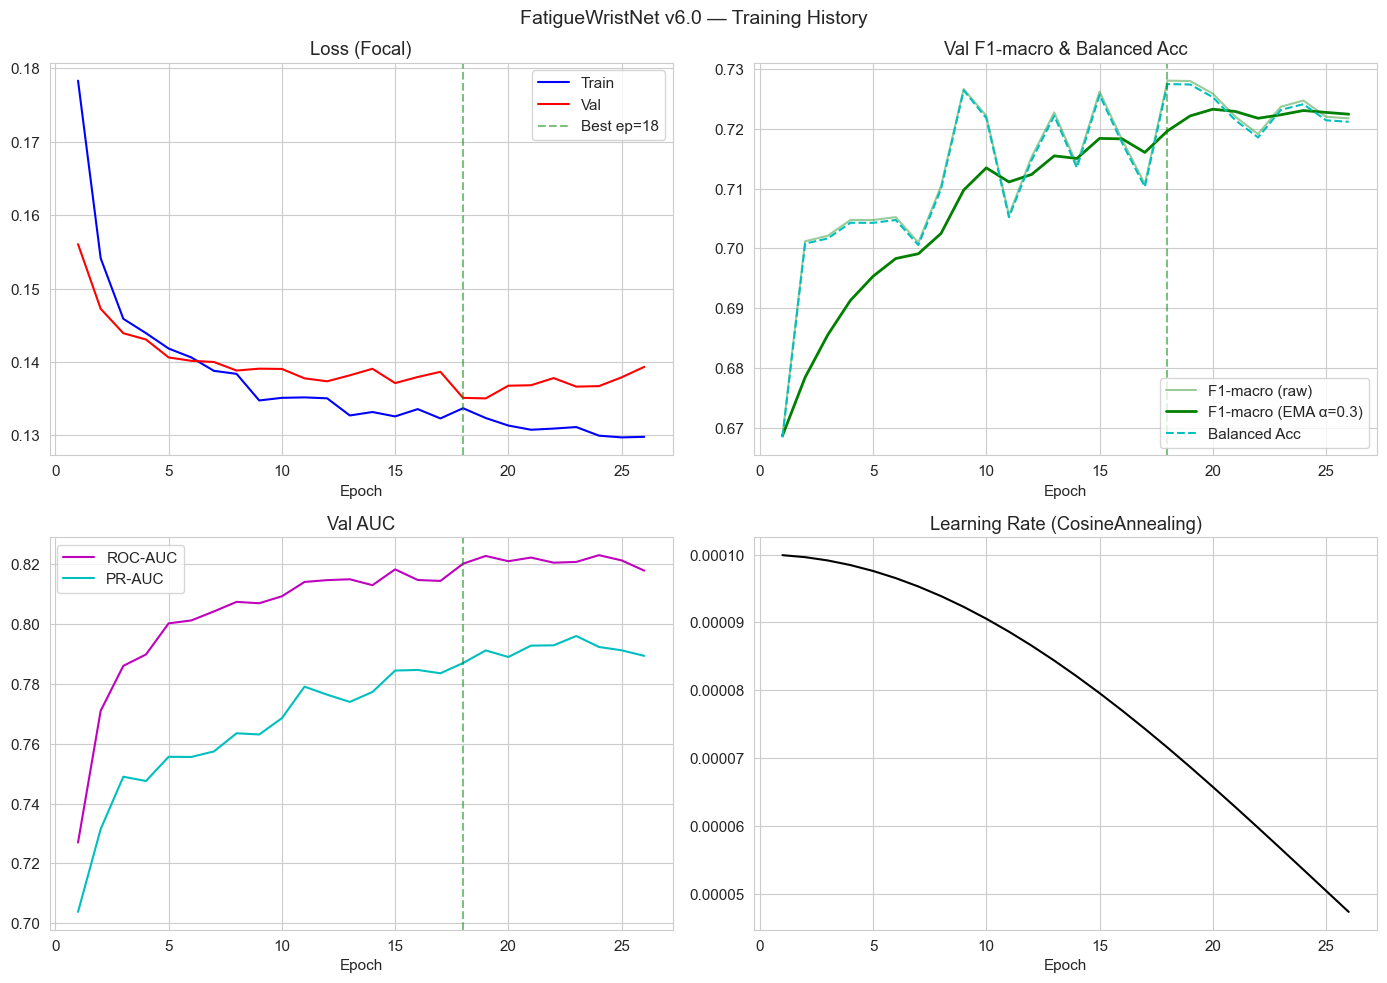

In [17]:
# ── Training history plots ──
print(CONFIG)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ep = range(1, len(history['train_loss']) + 1)

axes[0, 0].plot(ep, history['train_loss'], 'b-', label='Train')
axes[0, 0].plot(ep, history['val_loss'], 'r-', label='Val')
axes[0, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5, label=f'Best ep={best_epoch}')
axes[0, 0].set_title('Loss (Focal)')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Epoch')

axes[0, 1].plot(ep, history['val_f1'], 'g-', alpha=0.4, label='F1-macro (raw)')
axes[0, 1].plot(ep, history['val_f1_ema'], 'g-', lw=2, label='F1-macro (EMA α=0.3)')
axes[0, 1].plot(ep, history['val_bal_acc'], 'c--', label='Balanced Acc')
axes[0, 1].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[0, 1].set_title('Val F1-macro & Balanced Acc')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Epoch')

axes[1, 0].plot(ep, history['val_auc'], 'm-', label='ROC-AUC')
axes[1, 0].plot(ep, history['val_pr_auc'], 'c-', label='PR-AUC')
axes[1, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[1, 0].set_title('Val AUC')
axes[1, 0].legend()
axes[1, 0].set_xlabel('Epoch')

axes[1, 1].plot(ep, history['lr'], 'k-')
axes[1, 1].set_title('Learning Rate (CosineAnnealing)')
axes[1, 1].set_xlabel('Epoch')

plt.suptitle('FatigueWristNet v6.0 — Training History', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png')
plt.show()


{'batch_size': 32, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.005, 'patience': 6, 'min_delta': 0.0001, 'imu_channels': 6, 'encoder_channels': 32, 'encoder_dropout': 0.35, 'kernel_sizes': [7, 5, 3], 'physio_channels': 4, 'physio_encoder_channels': 16, 'classifier_dropout': 0.5, 'focal_gamma': 1.0, 'min_precision_for_recall': 0.3}


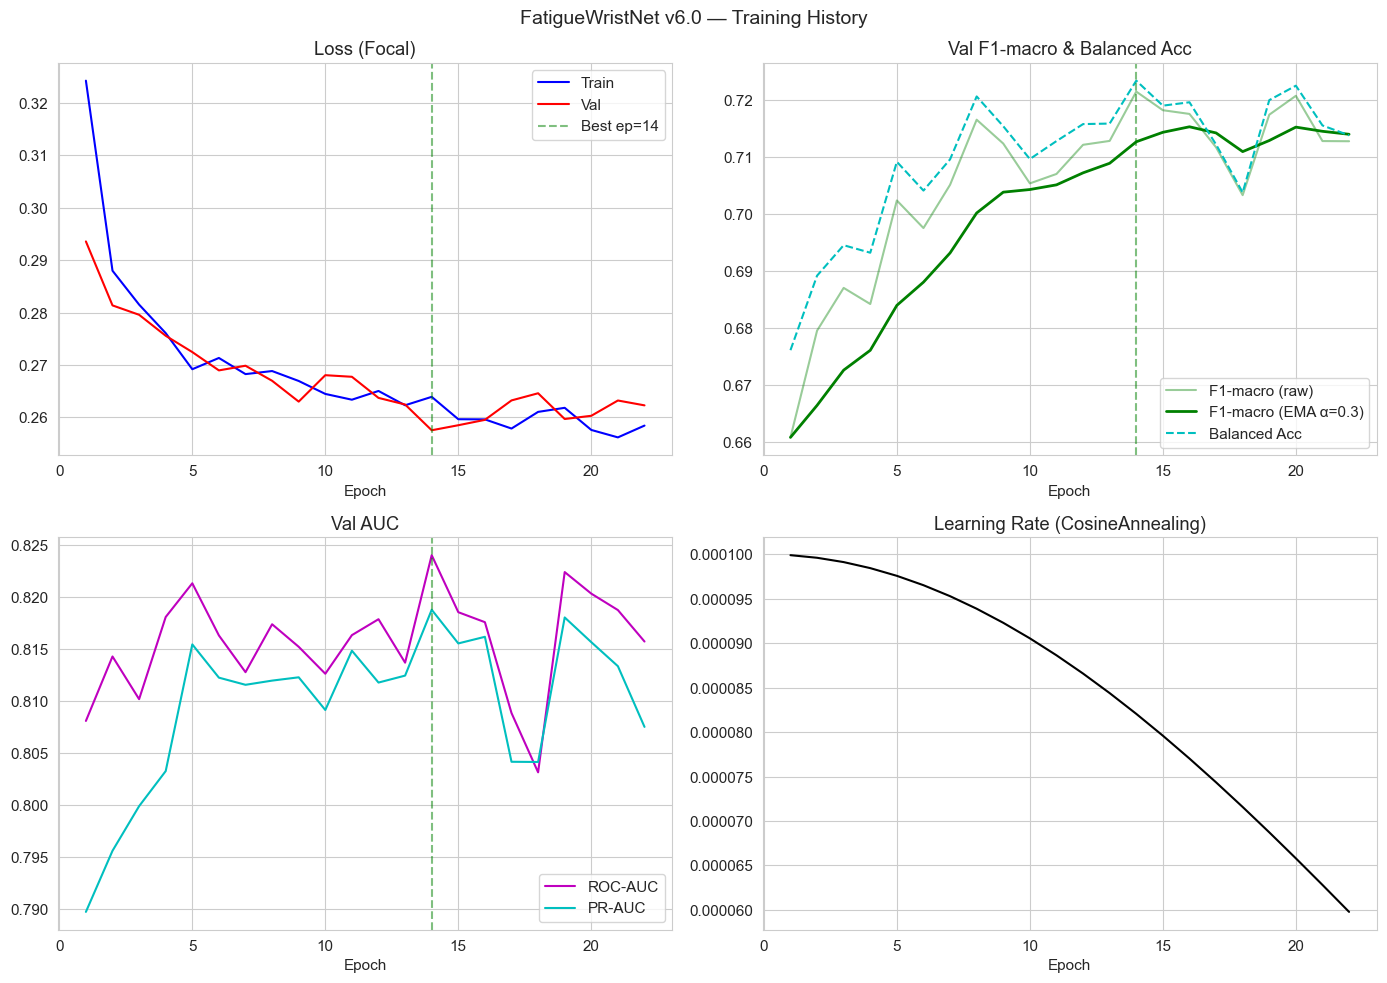

In [ ]:
# ── Training history plots ──
print(CONFIG)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ep = range(1, len(history['train_loss']) + 1)

axes[0, 0].plot(ep, history['train_loss'], 'b-', label='Train')
axes[0, 0].plot(ep, history['val_loss'], 'r-', label='Val')
axes[0, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5, label=f'Best ep={best_epoch}')
axes[0, 0].set_title('Loss (Focal)')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Epoch')

axes[0, 1].plot(ep, history['val_f1'], 'g-', alpha=0.4, label='F1-macro (raw)')
axes[0, 1].plot(ep, history['val_f1_ema'], 'g-', lw=2, label='F1-macro (EMA α=0.3)')
axes[0, 1].plot(ep, history['val_bal_acc'], 'c--', label='Balanced Acc')
axes[0, 1].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[0, 1].set_title('Val F1-macro & Balanced Acc')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Epoch')

axes[1, 0].plot(ep, history['val_auc'], 'm-', label='ROC-AUC')
axes[1, 0].plot(ep, history['val_pr_auc'], 'c-', label='PR-AUC')
axes[1, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[1, 0].set_title('Val AUC')
axes[1, 0].legend()
axes[1, 0].set_xlabel('Epoch')

axes[1, 1].plot(ep, history['lr'], 'k-')
axes[1, 1].set_title('Learning Rate (CosineAnnealing)')
axes[1, 1].set_xlabel('Epoch')

plt.suptitle('FatigueWristNet v6.0 — Training History', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png')
plt.show()


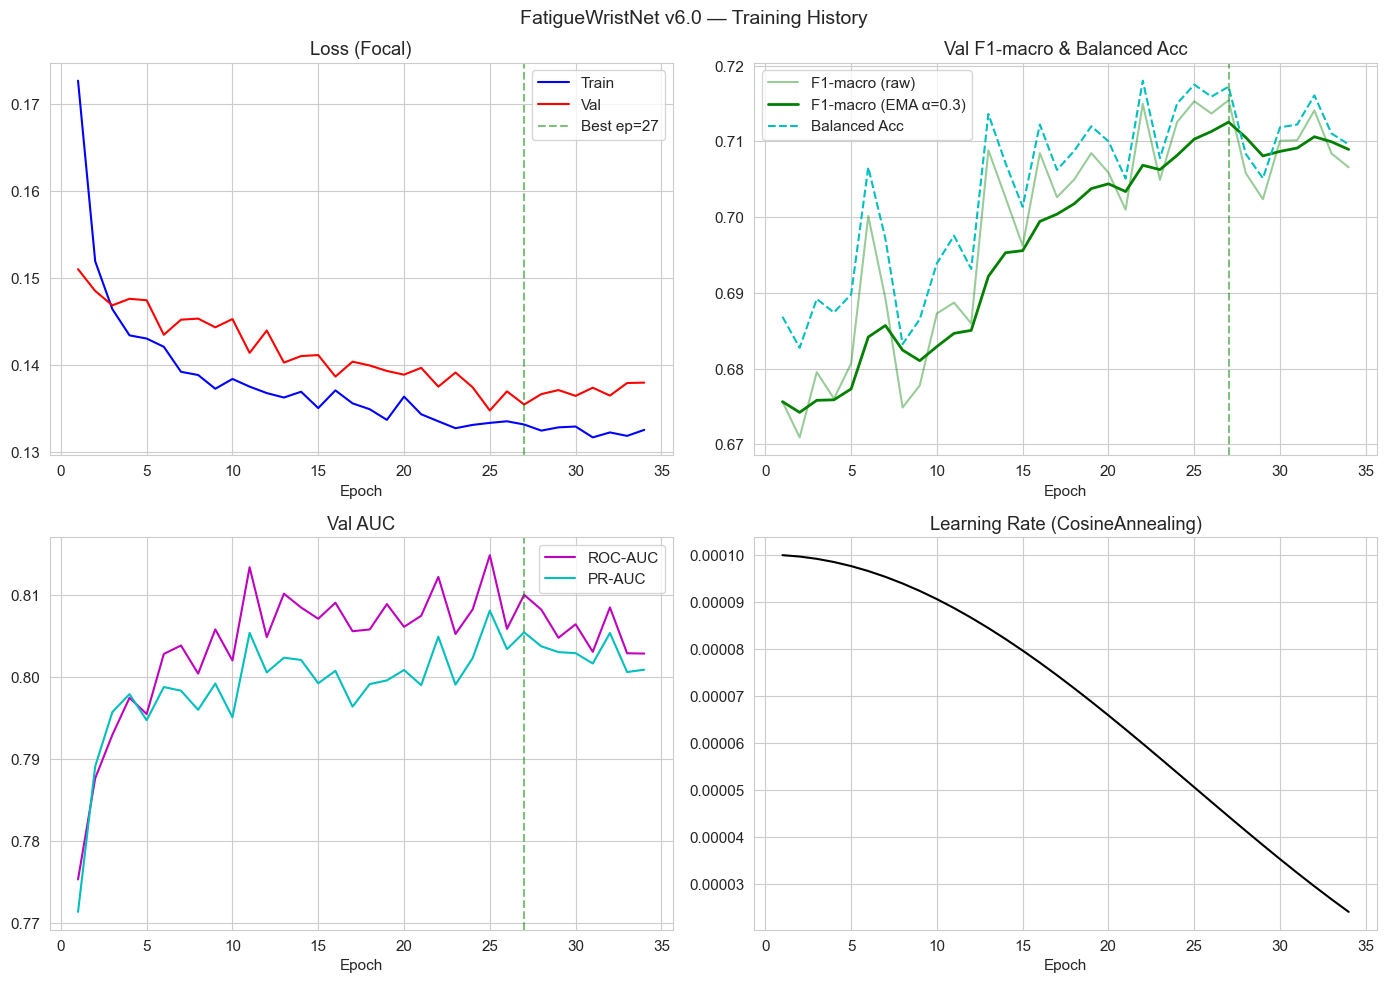

In [ ]:
# ── Training history plots ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ep = range(1, len(history['train_loss']) + 1)

axes[0, 0].plot(ep, history['train_loss'], 'b-', label='Train')
axes[0, 0].plot(ep, history['val_loss'], 'r-', label='Val')
axes[0, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5, label=f'Best ep={best_epoch}')
axes[0, 0].set_title('Loss (Focal)')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Epoch')

axes[0, 1].plot(ep, history['val_f1'], 'g-', alpha=0.4, label='F1-macro (raw)')
axes[0, 1].plot(ep, history['val_f1_ema'], 'g-', lw=2, label='F1-macro (EMA α=0.3)')
axes[0, 1].plot(ep, history['val_bal_acc'], 'c--', label='Balanced Acc')
axes[0, 1].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[0, 1].set_title('Val F1-macro & Balanced Acc')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Epoch')

axes[1, 0].plot(ep, history['val_auc'], 'm-', label='ROC-AUC')
axes[1, 0].plot(ep, history['val_pr_auc'], 'c-', label='PR-AUC')
axes[1, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[1, 0].set_title('Val AUC')
axes[1, 0].legend()
axes[1, 0].set_xlabel('Epoch')

axes[1, 1].plot(ep, history['lr'], 'k-')
axes[1, 1].set_title('Learning Rate (CosineAnnealing)')
axes[1, 1].set_xlabel('Epoch')

plt.suptitle('FatigueWristNet v6.0 — Training History', fontsize=14)
plt.tight_layout()
plt.show()


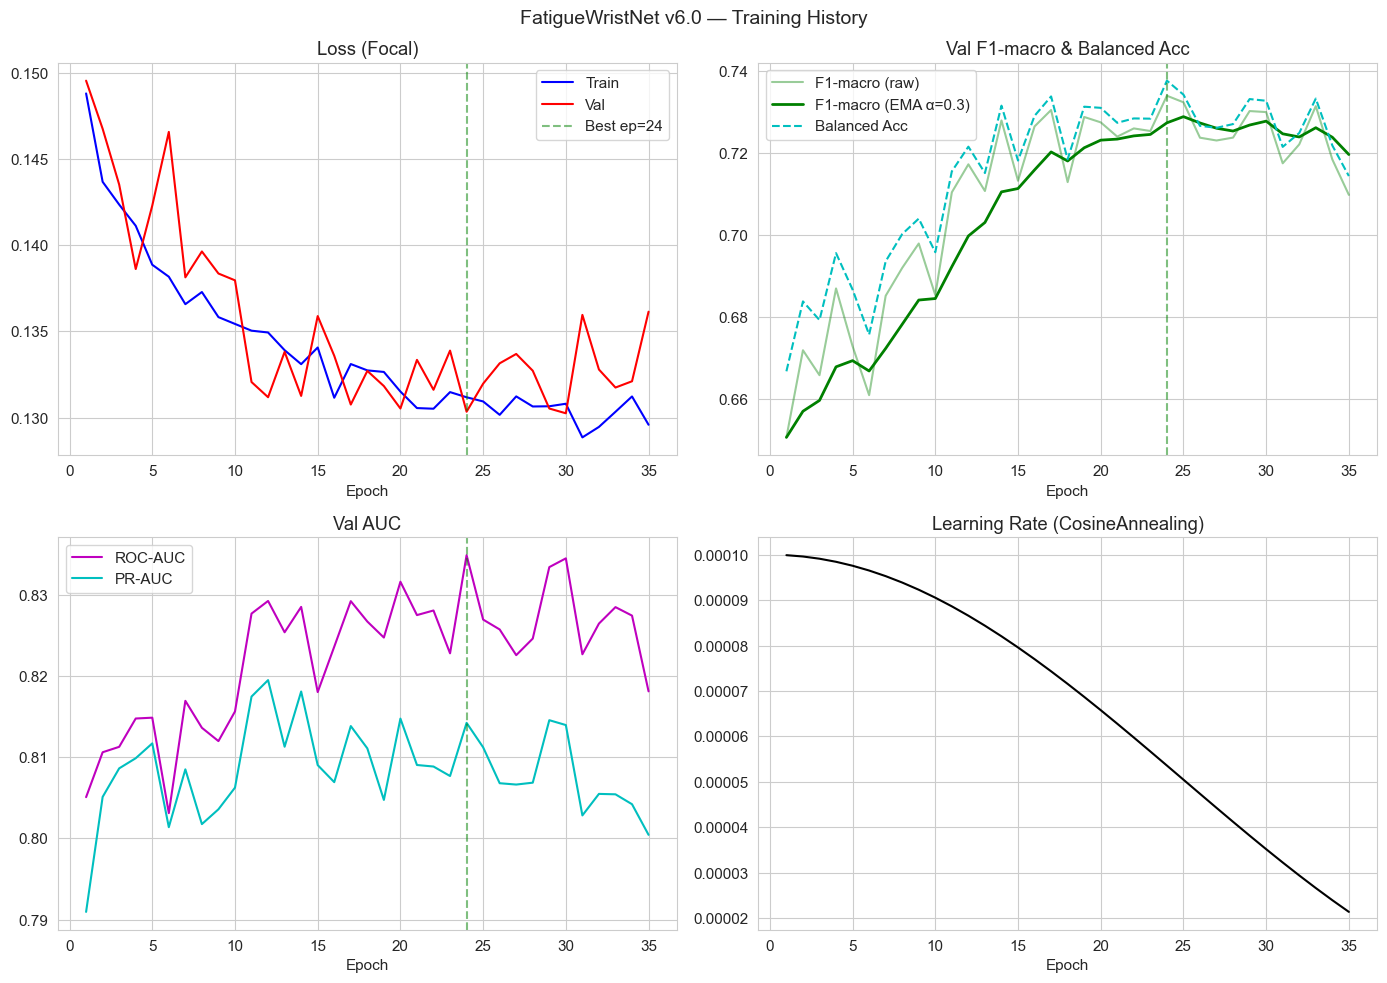

In [ ]:
# ── Training history plots ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ep = range(1, len(history['train_loss']) + 1)

axes[0, 0].plot(ep, history['train_loss'], 'b-', label='Train')
axes[0, 0].plot(ep, history['val_loss'], 'r-', label='Val')
axes[0, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5, label=f'Best ep={best_epoch}')
axes[0, 0].set_title('Loss (Focal)')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Epoch')

axes[0, 1].plot(ep, history['val_f1'], 'g-', alpha=0.4, label='F1-macro (raw)')
axes[0, 1].plot(ep, history['val_f1_ema'], 'g-', lw=2, label='F1-macro (EMA α=0.3)')
axes[0, 1].plot(ep, history['val_bal_acc'], 'c--', label='Balanced Acc')
axes[0, 1].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[0, 1].set_title('Val F1-macro & Balanced Acc')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Epoch')

axes[1, 0].plot(ep, history['val_auc'], 'm-', label='ROC-AUC')
axes[1, 0].plot(ep, history['val_pr_auc'], 'c-', label='PR-AUC')
axes[1, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[1, 0].set_title('Val AUC')
axes[1, 0].legend()
axes[1, 0].set_xlabel('Epoch')

axes[1, 1].plot(ep, history['lr'], 'k-')
axes[1, 1].set_title('Learning Rate (CosineAnnealing)')
axes[1, 1].set_xlabel('Epoch')

plt.suptitle('FatigueWristNet v6.0 — Training History', fontsize=14)
plt.tight_layout()
plt.show()


До SMOTE и аугментации:

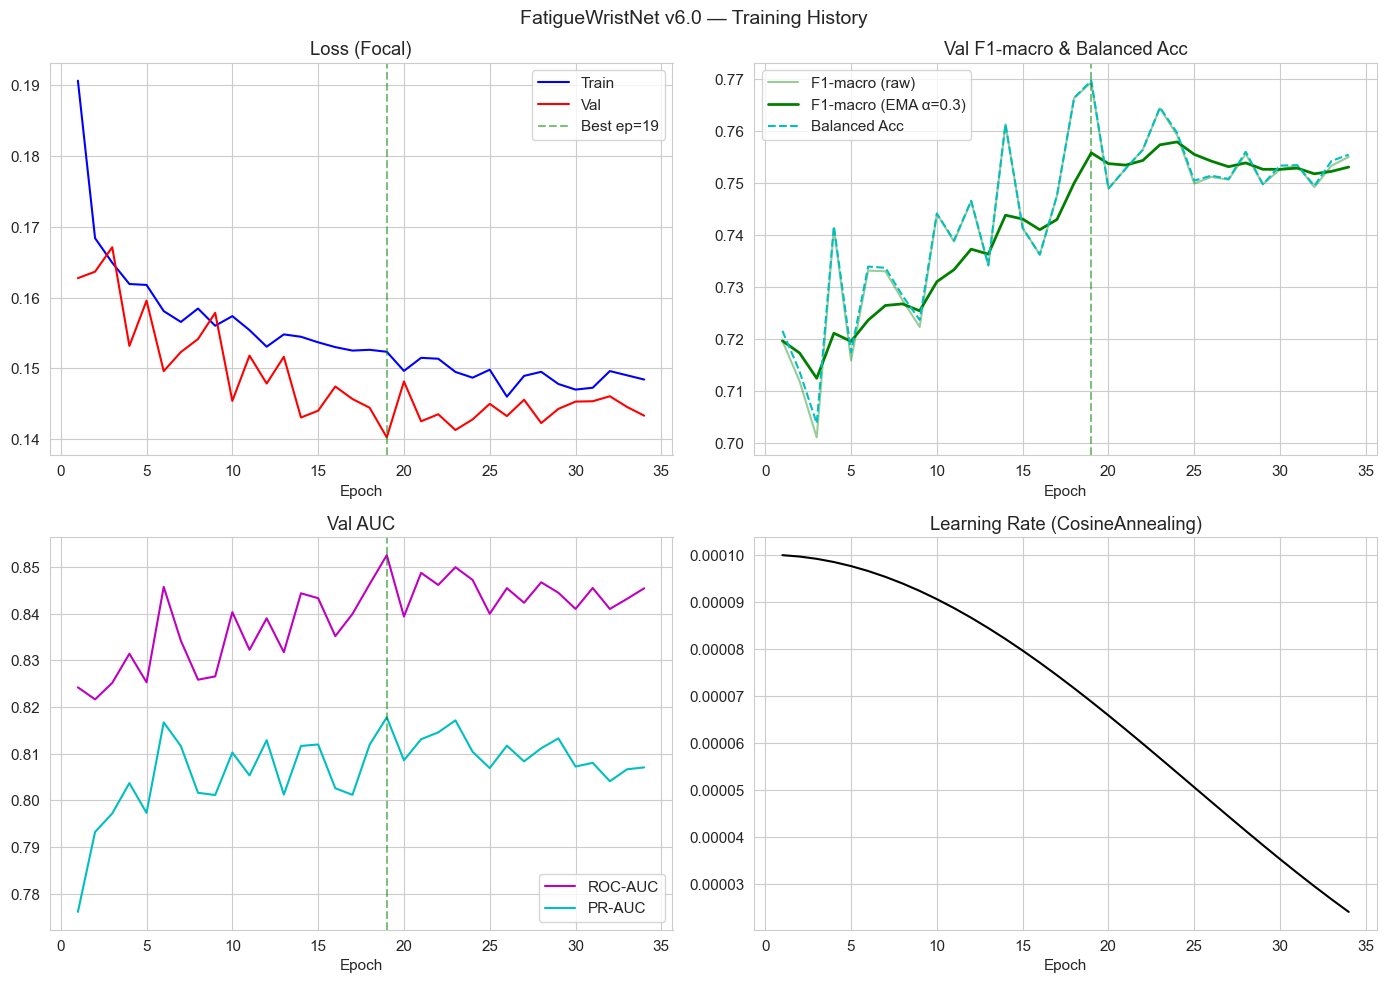

In [ ]:
# ── Training history plots ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ep = range(1, len(history['train_loss']) + 1)

axes[0, 0].plot(ep, history['train_loss'], 'b-', label='Train')
axes[0, 0].plot(ep, history['val_loss'], 'r-', label='Val')
axes[0, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5, label=f'Best ep={best_epoch}')
axes[0, 0].set_title('Loss (Focal)')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Epoch')

axes[0, 1].plot(ep, history['val_f1'], 'g-', alpha=0.4, label='F1-macro (raw)')
axes[0, 1].plot(ep, history['val_f1_ema'], 'g-', lw=2, label='F1-macro (EMA α=0.3)')
axes[0, 1].plot(ep, history['val_bal_acc'], 'c--', label='Balanced Acc')
axes[0, 1].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[0, 1].set_title('Val F1-macro & Balanced Acc')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Epoch')

axes[1, 0].plot(ep, history['val_auc'], 'm-', label='ROC-AUC')
axes[1, 0].plot(ep, history['val_pr_auc'], 'c-', label='PR-AUC')
axes[1, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[1, 0].set_title('Val AUC')
axes[1, 0].legend()
axes[1, 0].set_xlabel('Epoch')

axes[1, 1].plot(ep, history['lr'], 'k-')
axes[1, 1].set_title('Learning Rate (CosineAnnealing)')
axes[1, 1].set_xlabel('Epoch')

plt.suptitle('FatigueWristNet v6.0 — Training History', fontsize=14)
plt.tight_layout()
plt.show()


## 6. Оценка на тестовой выборке

Два порога:
1. **F1-optimal** — максимизирует F1-macro (как в v5.1)
2. **Recall-optimal** — максимизирует recall(usталость) при precision ≥ 0.3 (новое в v6.0)

In [18]:
# ── Test evaluation ──
test_loss, test_metrics, test_labels, test_probs = validate(
    model, test_loader, criterion, DEVICE, threshold=best_threshold, return_raw=True)
_, test_preds = compute_binary_metrics(test_labels, test_probs, best_threshold)

# Recall-optimized threshold
recall_thresh, recall_val = find_recall_optimized_threshold(
    test_labels, test_probs, min_precision=CONFIG['min_precision_for_recall'])

print("=" * 60)
print("TEST RESULTS (FatigueWristNet v6.0)")
print("=" * 60)

print(f"\n📊 F1-optimal threshold = {best_threshold:.3f}:")
print(f"   F1-macro:      {test_metrics['f1_macro']:.4f}")
print(f"   ROC-AUC:       {test_metrics['roc_auc']:.4f}")
print(f"   PR-AUC:        {test_metrics['pr_auc']:.4f}")
print(f"   Balanced Acc:  {test_metrics['balanced_acc']:.4f}")
print(f"\n   Classification Report:")
print(classification_report(
    test_labels, test_preds, target_names=['Normal', 'Fatigue'], zero_division=0))

print(f"📊 Recall-optimized threshold = {recall_thresh:.3f} (recall={recall_val:.3f}):")
recall_metrics, recall_preds = compute_binary_metrics(
    test_labels, test_probs, recall_thresh)
print(f"   F1-macro:      {recall_metrics['f1_macro']:.4f}")
print(f"   Balanced Acc:  {recall_metrics['balanced_acc']:.4f}")
print(classification_report(
    test_labels, (test_probs >= recall_thresh).astype(int),
    target_names=['Normal', 'Fatigue'], zero_division=0))

TEST RESULTS (FatigueWristNet v6.0)

📊 F1-optimal threshold = 0.405:
   F1-macro:      0.7643
   ROC-AUC:       0.8334
   PR-AUC:        0.8149
   Balanced Acc:  0.7665

   Classification Report:
              precision    recall  f1-score   support

      Normal       0.86      0.64      0.73      2522
     Fatigue       0.72      0.90      0.80      2641

    accuracy                           0.77      5163
   macro avg       0.79      0.77      0.76      5163
weighted avg       0.79      0.77      0.77      5163

📊 Recall-optimized threshold = 0.050 (recall=1.000):
   F1-macro:      0.3384
   Balanced Acc:  0.5000
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      2522
     Fatigue       0.51      1.00      0.68      2641

    accuracy                           0.51      5163
   macro avg       0.26      0.50      0.34      5163
weighted avg       0.26      0.51      0.35      5163



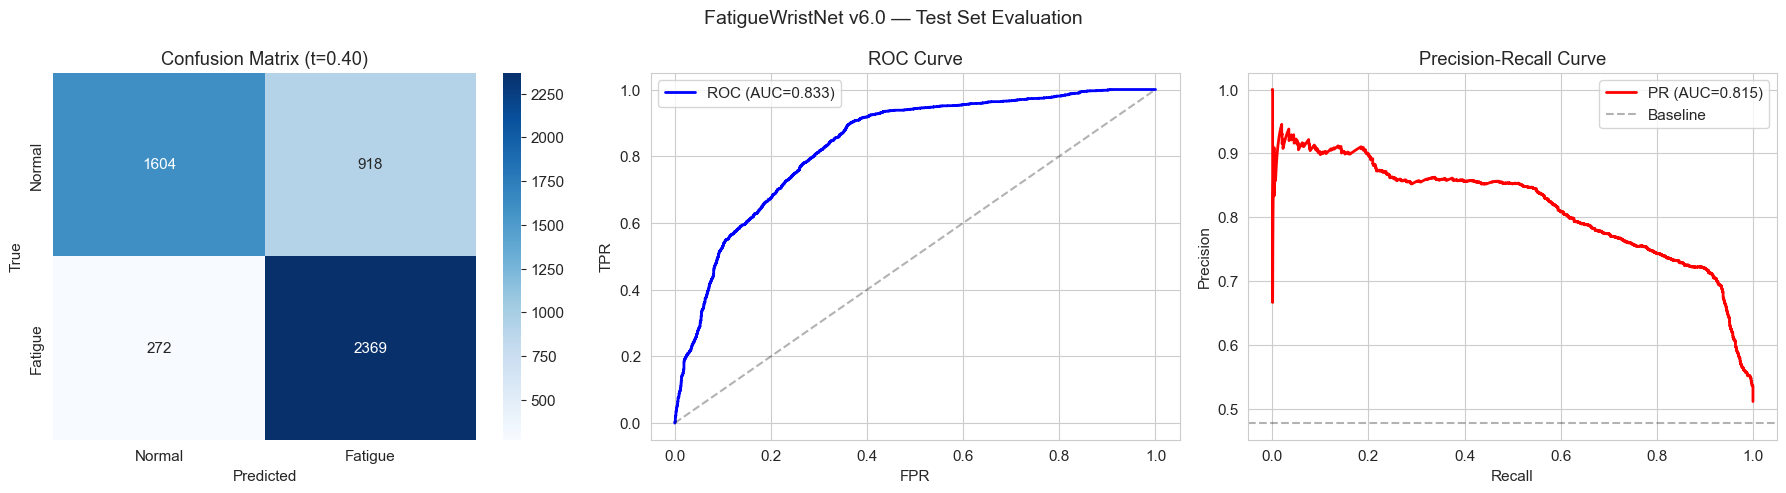

In [19]:
# ── Confusion Matrix + ROC/PR Curves ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix (F1-threshold)
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fatigue'], yticklabels=['Normal', 'Fatigue'])
axes[0].set_title(f'Confusion Matrix (t={best_threshold:.2f})')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC={test_metrics["roc_auc"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')

# PR curve
pr_vals, rc_vals, _ = precision_recall_curve(test_labels, test_probs)
axes[2].plot(rc_vals, pr_vals, 'r-', lw=2,
             label=f'PR (AUC={test_metrics["pr_auc"]:.3f})')
axes[2].axhline(y_all.mean(), color='k', ls='--', alpha=0.3, label='Baseline')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

plt.suptitle('FatigueWristNet v6.0 — Test Set Evaluation', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'test_set_evaluation.png')
plt.show()

## 7. LOSO Evaluation (Leave-One-Subject-Out)

Строгая оценка обобщения: обучение на N-1 субъектов, тест на оставшемся.
PhysioNet + WSD4FEDSRM (до ~97 субъектов, ограничено n_folds для скорости).

In [22]:
# ── LOSO Evaluation (v6.0: FatigueWristNet, PhysioNet + WSD4FEDSRM) ──

def loso_evaluation(X_imu, X_physio, y, subjects, domains, has_physio,
                    n_folds=20, epochs=25, min_windows=20, patience=5):
    """LOSO with dual-branch model, Focal Loss, and fold limit."""
    unique_subj = np.unique(subjects)
    folds = [{'train_idx': np.where(subjects != s)[0],
              'test_idx': np.where(subjects == s)[0], 'subject': s}
             for s in unique_subj]

    # Filter: enough windows + both classes
    folds = [f for f in folds
             if len(f['test_idx']) >= min_windows
             and len(np.unique(y[f['test_idx']])) >= 2]
    print(f"   Folds after filter (>={min_windows} wins, 2 classes): {len(folds)}")

    if len(folds) > n_folds:
        np.random.seed(SEED)
        folds = [folds[i] for i in np.random.choice(len(folds), n_folds, replace=False)]

    results = []

    for fold in tqdm(folds, desc='LOSO'):
        tr, te = fold['train_idx'], fold['test_idx']

        # Mini val split for early stopping
        try:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
            sub_tr, sub_val = next(sss.split(tr, y[tr]))
            vi, ti = tr[sub_val], tr[sub_tr]
        except ValueError:
            ti, vi = tr, te

        tr_ds = FatigueDataset(X_imu[ti], X_physio[ti], y[ti], has_physio[ti], augment=True)
        va_ds = FatigueDataset(X_imu[vi], X_physio[vi], y[vi], has_physio[vi])
        te_ds = FatigueDataset(X_imu[te], X_physio[te], y[te], has_physio[te])

        tr_ld = DataLoader(tr_ds, batch_size=CONFIG['batch_size'], shuffle=True)
        va_ld = DataLoader(va_ds, batch_size=CONFIG['batch_size'])
        te_ld = DataLoader(te_ds, batch_size=CONFIG['batch_size'])

        m = FatigueWristNet(CONFIG).to(DEVICE)
        pw = compute_pos_weight(y[ti])
        crit = FocalLoss(gamma=CONFIG['focal_gamma'],
                         pos_weight=torch.tensor([pw]).to(DEVICE))
        opt = optim.AdamW(m.parameters(), lr=3e-4, weight_decay=3e-4)

        best_f1, best_st, no_imp = -np.inf, None, 0
        for ep in range(epochs):
            train_epoch(m, tr_ld, opt, crit, DEVICE)
            _, vm = validate(m, va_ld, crit, DEVICE)
            if vm['f1_macro'] > best_f1 + 1e-4:
                best_f1 = vm['f1_macro']
                best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}
                no_imp = 0
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

        if best_st:
            m.load_state_dict(best_st)

        _, tm = validate(m, te_ld, crit, DEVICE)

        results.append({
            'subject': fold['subject'],
            'domain': domains[te][0],
            'f1_macro': tm['f1_macro'],
            'roc_auc': tm['roc_auc'],
            'n_samples': len(te),
        })

    return pd.DataFrame(results)


# Run LOSO
print("Running LOSO (v6.0: FatigueWristNet, PhysioNet + WSD4FEDSRM)...")
loso_results = loso_evaluation(
    X_imu_all, X_physio_all, y_all, subjects, domains, has_physio,
    n_folds=10, epochs=15, min_windows=20, patience=CONFIG['patience'],
)

print("\n" + "=" * 60)
print("LOSO RESULTS (FatigueWristNet v6.0)")
print("=" * 60)
print(loso_results.to_string(index=False))
print(f"\nOverall: F1={loso_results['f1_macro'].mean():.4f}"
      f"±{loso_results['f1_macro'].std():.4f}, "
      f"AUC={loso_results['roc_auc'].mean(skipna=True):.4f}"
      f"±{loso_results['roc_auc'].std(skipna=True):.4f}")

for dom in loso_results['domain'].unique():
    d = loso_results[loso_results['domain'] == dom]
    print(f"  {dom}: F1={d['f1_macro'].mean():.4f}±{d['f1_macro'].std():.4f}, "
          f"AUC={d['roc_auc'].mean(skipna=True):.4f}, n={len(d)}")

Running LOSO (v6.0: FatigueWristNet, PhysioNet + WSD4FEDSRM)...
   Folds after filter (>=20 wins, 2 classes): 65


LOSO: 100%|██████████| 10/10 [1:05:25<00:00, 392.60s/it]


LOSO RESULTS (FatigueWristNet v6.0)
      subject     domain  f1_macro  roc_auc  n_samples
      wsd_031 wsd4fedsrm  0.340000 0.572151        132
      wsd_026 wsd4fedsrm  0.444444 0.570000        200
      wsd_023 wsd4fedsrm  0.395349 0.649918        104
      wsd_030 wsd4fedsrm  0.452381 0.313322         92
physionet_f01  physionet  0.849674 0.916860       1059
      wsd_019 wsd4fedsrm  0.383333 0.581910        148
      wsd_022 wsd4fedsrm  0.375000 0.724583        100
      wsd_024 wsd4fedsrm  0.431034 0.820938        132
      wsd_029 wsd4fedsrm  0.448980 0.664205        108
physionet_S05  physionet  0.769935 0.756188        618

Overall: F1=0.4890±0.1740, AUC=0.6570±0.1658
  wsd4fedsrm: F1=0.4088±0.0414, AUC=0.6121, n=8
  physionet: F1=0.8098±0.0564, AUC=0.8365, n=2


## 8. Персонализация (fine-tuning)

Дообучение на данных конкретного спортсмена:
1. **Stage 1:** заморозить энкодеры, обучить только classifier (10 эпох)
2. **Stage 2:** разморозить conv3 + attention, fine-tune с lr/10 (10 эпох)

In [23]:
# ── Personalization (v6.0: dual-branch fine-tuning) ──
import copy

def personalize_model(base_model, X_imu_subj, X_physio_subj, y_subj, has_physio_subj,
                      epochs_stage1=10, epochs_stage2=10, lr=1e-3):
    """Two-stage fine-tuning for a specific athlete."""
    model = copy.deepcopy(base_model)

    n = len(y_subj)
    split = max(int(n * 0.7), 2)
    idx = np.arange(n)
    np.random.shuffle(idx)
    ti, vi = idx[:split], idx[split:]

    if len(vi) < 2 or len(np.unique(y_subj[vi])) < 2:
        return model, {'f1_macro': np.nan, 'roc_auc': np.nan}

    tr_ds = FatigueDataset(X_imu_subj[ti], X_physio_subj[ti], y_subj[ti], has_physio_subj[ti])
    va_ds = FatigueDataset(X_imu_subj[vi], X_physio_subj[vi], y_subj[vi], has_physio_subj[vi])
    tr_ld = DataLoader(tr_ds, batch_size=min(16, len(ti)), shuffle=True)
    va_ld = DataLoader(va_ds, batch_size=min(16, len(vi)))

    pw = compute_pos_weight(y_subj[ti])
    crit = FocalLoss(gamma=2.0, pos_weight=torch.tensor([pw]).to(DEVICE))

    # Stage 1: freeze encoders, train classifier only
    for p in model.imu_encoder.parameters():
        p.requires_grad = False
    for p in model.physio_encoder.parameters():
        p.requires_grad = False
    opt1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    for _ in range(epochs_stage1):
        train_epoch(model, tr_ld, opt1, crit, DEVICE)

    # Stage 2: unfreeze conv3 + attention, fine-tune
    for p in model.imu_encoder.conv3.parameters():
        p.requires_grad = True
    for p in model.imu_encoder.attention.parameters():
        p.requires_grad = True
    opt2 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr / 10)
    for _ in range(epochs_stage2):
        train_epoch(model, tr_ld, opt2, crit, DEVICE)

    _, vm = validate(model, va_ld, crit, DEVICE)
    return model, vm


# Test personalization on a few subjects
test_subjects = np.unique(subjects[test_idx])[:5]
print("=" * 60)
print("PERSONALIZATION TEST (FatigueWristNet v6.0)")
print("=" * 60)

for subj in test_subjects:
    m = subjects == subj
    if np.unique(y_all[m]).size < 2 or m.sum() < 10:
        print(f"  {subj}: skipped (too few samples or 1 class)")
        continue
    pm, pv = personalize_model(
        model, X_imu_all[m], X_physio_all[m], y_all[m], has_physio[m])
    auc_str = f"{pv.get('roc_auc', np.nan):.4f}" if np.isfinite(pv.get('roc_auc', np.nan)) else "n/a"
    print(f"  {subj}: {m.sum()} wins, F1={pv['f1_macro']:.4f}, AUC={auc_str}")

PERSONALIZATION TEST (FatigueWristNet v6.0)
  physionet_S01: 633 wins, F1=0.9462, AUC=0.9920
  physionet_S04: 636 wins, F1=0.8567, AUC=0.9766
  physionet_S05: 618 wins, F1=0.9082, AUC=0.9685
  physionet_S07: 573 wins, F1=0.8134, AUC=0.9521
  physionet_f09: 872 wins, F1=0.9463, AUC=0.9934


## Итоги v6.0

**Изменения по сравнению с v5.1:**

| Аспект | v5.1 | v6.0 |
|--------|------|------|
| Домены | Zenodo + 4TU (поясница) | **PhysioNet + WSD4FEDSRM (запястье)** |
| Модель | FatigueCNN_Simple (IMU-only) | **FatigueWristNet (IMU + Physio)** |
| Loss | LabelSmoothingBCE | **Focal Loss** (γ=2.0) |
| Sampler | Domain-weighted only | **Class+Domain weighted** |
| CONFIG | Раздельные параметры с `//2` | **Единый CONFIG**, деление внутри модулей |
| Checkpoint | Только weights | **weights + CONFIG + threshold** |
| Threshold | F1-optimal | F1-optimal + **Recall-optimized** |

**Следующие шаги:**
- Пересборка `composite_full.npz` с WSD4FEDSRM `segment=Forearm` (вместо Sternum) для более релевантных запястных данных
- Hyperparameter tuning на новых данных
- v7.0: мультисегментная модель (4TU 8 IMU) для биомеханического анализа бега